# ML Project

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import all datasets

teams = pd.read_csv('../dataset_cleaned/teams.csv')
teams_post = pd.read_csv('../dataset_cleaned/teams_post.csv')
awards_players = pd.read_csv('../dataset_cleaned/awards_players.csv')
series_post = pd.read_csv('../dataset_cleaned/series_post.csv')
players = pd.read_csv('../dataset_cleaned/players.csv')
players_teams = pd.read_csv('../dataset_cleaned/players_teams.csv')
coaches = pd.read_csv('../dataset_cleaned/coaches.csv')


## Feature Engineering

In [37]:
# Calculate the number of player awards per team each year
if 'player_awards' in teams.columns:
    teams = teams.drop(columns=['player_awards'])
filtered_awards = awards_players[awards_players['award'] != "Coach of the Year"].copy()
award_counts = filtered_awards.groupby(['playerID', 'year']).size().reset_index(name='player_awards')
player_team_awards = pd.merge(award_counts, players_teams, on=['playerID', 'year'], how='inner')
player_team_awards = player_team_awards.dropna(subset=['tmID'])
team_awards = player_team_awards.groupby(['tmID', 'year'])['player_awards'].sum().reset_index()
teams = pd.merge(teams, team_awards[['tmID', 'year', 'player_awards']], on=['tmID', 'year'], how='left')
teams['player_awards'] = teams['player_awards'].fillna(0).astype(int)

# Measures how much a team outscores its opponents per game
teams["net_rating"] = (teams["o_pts"] - teams["d_pts"]) / teams["GP"]

teams["off_eff"] = teams["o_pts"] / teams["o_fga"]   # points per field goal attempt
teams["def_eff"] = teams["d_pts"] / teams["d_fga"]   # points allowed per opponent FGA

# Measures how effectively the team scores compared to what they allow
teams["eff_diff"] = teams["off_eff"] - teams["def_eff"]

# Calculate the Home vs Away Win Ratio (small gap means consistency)
teams["home_win_pct"] = teams["homeW"] / (teams["homeW"] + teams["homeL"])
teams["away_win_pct"] = teams["awayW"] / (teams["awayW"] + teams["awayL"])
teams["home_away_balance"] = teams["away_win_pct"] - teams["home_win_pct"]

# Calculate the difference between the turnovers of the opponents and the turnovers of the team
teams["to_dif"] = teams["d_to"] - teams["o_to"]

# Calculate the difference between the rebounds gained by the team and the ones gained by the opponents
teams["reb_dif"] = teams["o_reb"] - teams["d_reb"]

# Calculate the offensive rebound difference (extra scoring opportunities created by the team)
teams["off_reb_dif"] = teams["o_oreb"] - teams["d_dreb"]

# Calculate the defensive rebound difference (how well the team prevents second-chance points)
teams["def_reb_dif"] = teams["o_dreb"] - teams["d_oreb"]

# Calculate the percentage of all total rebounds captured by the team
teams["reb_pct"] = teams["o_reb"] / (teams["o_reb"] + teams["d_reb"])

# Calculate the percentage of offensive rebounds captured by the team (offensive efficiency)
teams["off_reb_pct"] = teams["o_oreb"] / (teams["o_oreb"] + teams["d_dreb"])

# Calculate the percentage of defensive rebounds captured by the team (defensive efficiency)
teams["def_reb_pct"] = teams["o_dreb"] / (teams["o_dreb"] + teams["d_oreb"])

# Calculate the percentage of conference wins per team
teams["conf_win_pct"] = teams["confW"] / (teams["confW"] + teams["confL"])

# Calculate the difference in assists between the team and its opponents
teams["ast_dif"] = teams["o_asts"] - teams["d_asts"]

# Calculate the difference in steals between the team and its opponents
teams["stl_dif"] = teams["o_stl"] - teams["d_stl"]

# Calculate the difference in blocks between the team and its opponents
teams["blk_dif"] = teams["o_blk"] - teams["d_blk"]

# Calculate the difference in personal fouls committed by the team and the opponent
teams["pf_dif"] = teams["o_pf"] - teams["d_pf"]

# Calculate the assist-to-turnover ratio (assists to turnovers ratio) for the team
teams["ast_to_to"] = teams["o_asts"] / (teams["o_to"] + 1e-5)

# Calculate the steal-to-turnover ratio (steals to turnovers ratio) for the team
teams["stl_to_to"] = teams["o_stl"] / (teams["o_to"] + 1e-5)

# Calculate the block-to-turnover ratio (blocks to turnovers ratio) for the team
teams["blk_to_to"] = teams["o_blk"] / (teams["o_to"] + 1e-5)

# Calculate the number of coach awards per team each year
if 'coach_awards' in teams.columns:
    teams = teams.drop(columns=['coach_awards'])
coach_awards = awards_players[awards_players['award'] == 'Coach of the Year'].copy()
coach_awards_count = coach_awards.groupby(['playerID', 'year']).size().reset_index(name='coach_awards')
coach_awards_with_team = pd.merge(coach_awards_count, coaches, left_on=['playerID', 'year'], right_on=['coachID', 'year'], how='inner')
coach_team_awards = coach_awards_with_team[['tmID', 'year', 'coach_awards']].drop_duplicates()
teams = pd.merge(teams, coach_team_awards, on=['tmID', 'year'], how='left')
teams['coach_awards'] = teams['coach_awards'].fillna(0).astype(int)

# Calculate win percentage
teams["win_pct"] = teams["won"] / (teams["won"] + teams["lost"])

# Calculate offensive field goal percentage
teams["fg_pct"] = teams["o_fgm"] / (teams["o_fgm"] + teams["o_fga"])

# Calculate 3 points made percentage
teams["3p_pct"] = teams["o_3pm"] / (teams["o_3pm"] + teams["o_3pa"])

# Calculate point average (made points vs allowed points)
teams["pa_pct"] = teams["o_pts"] / (teams["o_pts"] + teams["d_pts"])

# Calculate free throw percentage (offensive free throws made vs. offensive free throws attempted)
teams["ft_pct"] = teams["o_ftm"] / (teams["o_ftm"] + teams["o_fta"])


## Feature Selection

In [45]:
feature_selection_columns = [
    'player_awards',
    'net_rating',
    'off_eff',
    'def_eff',
    'eff_diff',
    'home_win_pct',
    'away_win_pct',
    'home_away_balance',
    'to_dif',
    'reb_dif',
    'off_reb_dif',
    'def_reb_dif',
    'reb_pct',
    'off_reb_pct',
    'def_reb_pct',
    'conf_win_pct',
    'ast_dif',
    'stl_dif',
    'blk_dif',
    'pf_dif',
    'ast_to_to',
    'stl_to_to',
    'blk_to_to',
    'coach_awards',
    'win_pct',
    'fg_pct',
    '3p_pct',
    'pa_pct',
    'ft_pct'
]

teams[feature_selection_columns].head(10)

# Correlations between features and target variable (rank)
CORR_THRESHOLD = 0.3

corr = teams[["rank"] + feature_selection_columns].corr()

# Filter out all features with low correlation given the correlation threshold
strong_corr = corr["rank"][corr["rank"].abs() >= CORR_THRESHOLD]

strong_corr.sort_values()


win_pct         -0.887239
conf_win_pct    -0.868701
pa_pct          -0.811704
net_rating      -0.810810
home_win_pct    -0.792679
away_win_pct    -0.765164
eff_diff        -0.697435
ast_dif         -0.575608
fg_pct          -0.529524
off_eff         -0.497779
player_awards   -0.455101
reb_pct         -0.430791
def_reb_dif     -0.424939
reb_dif         -0.424061
ast_to_to       -0.407428
def_reb_pct     -0.372688
blk_dif         -0.367617
coach_awards    -0.314351
pf_dif           0.305900
def_eff          0.557654
rank             1.000000
Name: rank, dtype: float64

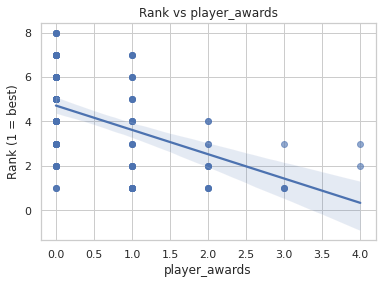

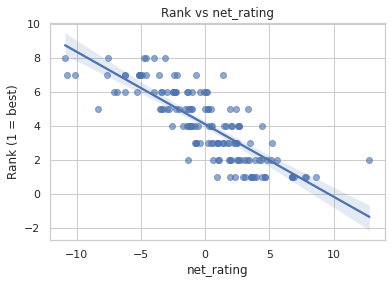

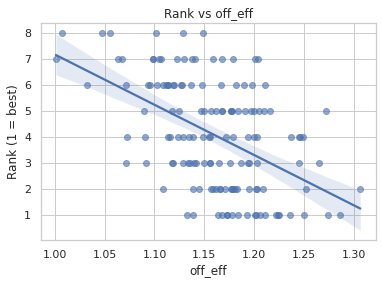

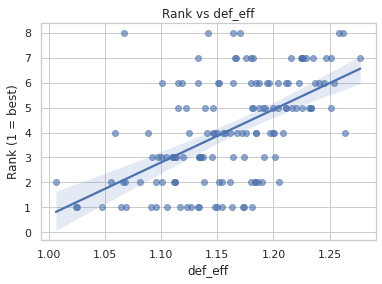

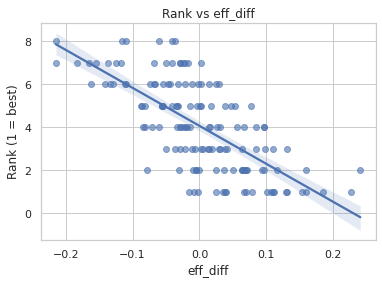

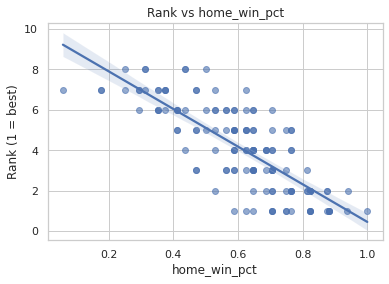

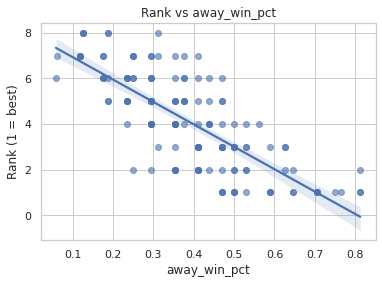

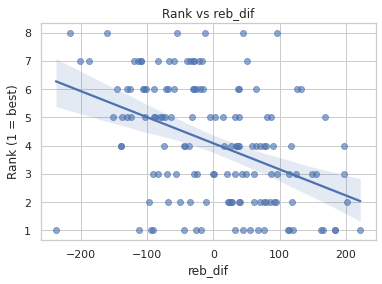

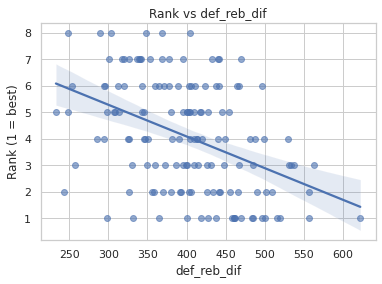

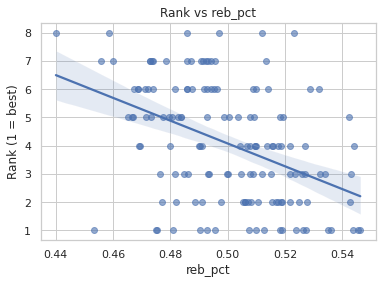

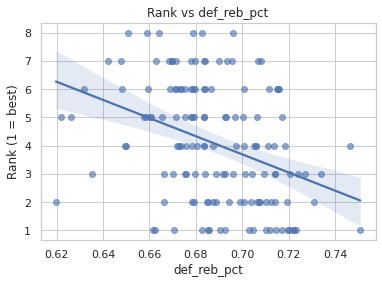

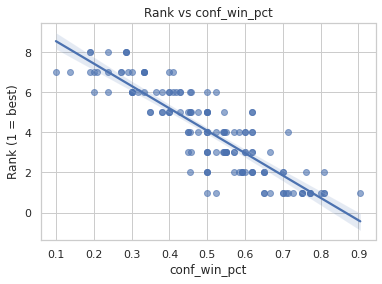

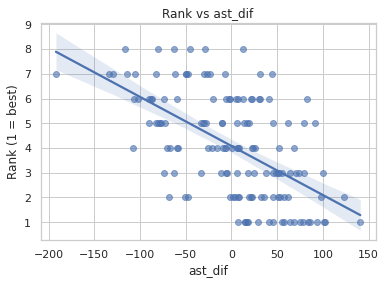

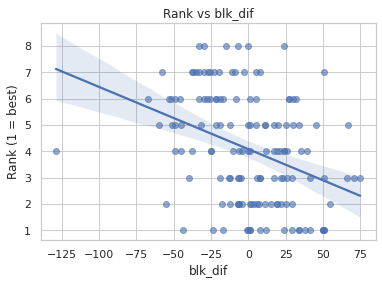

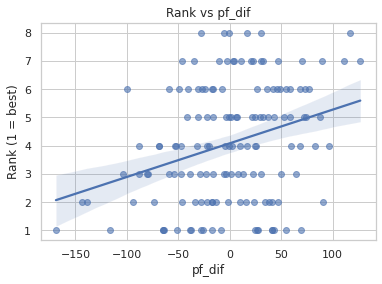

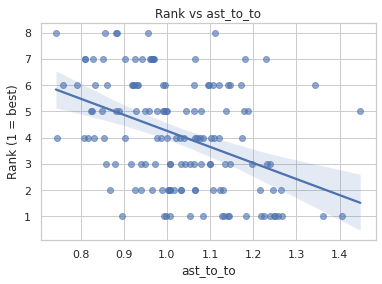

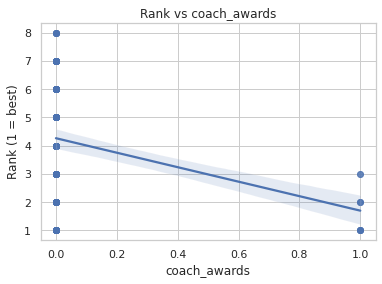

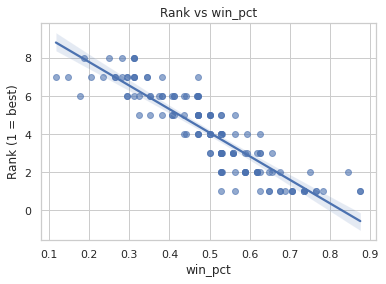

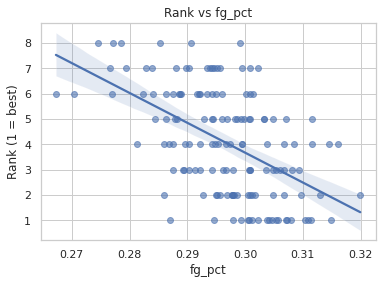

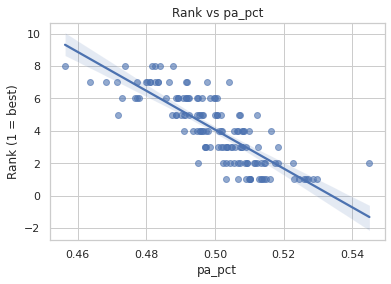

In [46]:
# Visualize the correlations
sns.set(style="whitegrid", context="notebook")

for col in strong_corr.index:
    if col == "rank":
        continue
    
    plt.figure(figsize=(6, 4))
    sns.regplot(x=col, y="rank", data=teams, scatter_kws={"alpha":0.6})
    plt.title(f"Rank vs {col}")
    plt.xlabel(col)
    plt.ylabel("Rank (1 = best)")
    plt.show()
